In [ ]:
# What's Inside The dataset contains 
# state-wise month-wise tourism data including:
# Domestic & Foreign Tourist arrivals 
# Tourism Revenue(INR Crore) 
# Revenue per tourist estimates Seasonality Index 
# & Seasonality Ratio Purpose of Visit (Leisure, Business, Religious, Adventure, Medical) 
# Year-over-year growth % 

# Potential Use Cases Analyzing tourism trends across 
# 1. Indian states Comparing domestic vs. foreign tourist behavior 
# 2. Seasonality and peak travel period analysis 
# 3. Revenue forecasting  


In [834]:
import pandas as pd
import numpy as nb
import seaborn as sb
import matplotlib.pyplot as plt

In [835]:
df = pd.read_csv('India_Tourism_2025_Processed.csv')

In [836]:
df.head()

,State,Month,Date,Month_Number,Domestic Tourists,Foreign Tourists,Total Tourists,Tourism Revenue (INR Crore),Revenue_Per_Tourist_INR,Domestic_Spend_Per_Person_Crore,Foreign_Spend_Per_Person_Crore,Est_Domestic_Revenue_Crore,Est_Foreign_Revenue_Crore,Domestic_Revenue_Percent,Foreign_Revenue_Percent,Annual_Avg_Revenue,Seasonality_Index,Seasonality_Ratio,Purpose of Visit,Growth % (Approx.)
0,Andaman & Nicobar Islands,January,2025-01-01,1,2539148,68865,2608013,53.89,206.632406,0.000019,0.000077,48.615895,5.274105,90.213202,9.786798,38.975,38.268121,1.382681,Adventure,6.38
1,Andaman & Nicobar Islands,February,2025-02-01,2,4187930,44980,4232910,101.25,239.197148,0.000023,0.000093,97.079321,4.170679,95.880811,4.119189,38.975,159.781911,2.597819,Business,6.33
2,Andaman & Nicobar Islands,March,2025-03-01,3,149336,99155,248491,5.73,230.591852,0.000010,0.000042,1.567334,4.162666,27.353120,72.646880,38.975,-85.298268,0.147017,Religious,-4.56
3,Andaman & Nicobar Islands,April,2025-04-01,4,473311,19820,493131,4.92,99.770649,0.000009,0.000036,4.214130,0.705870,85.653042,14.346958,38.975,-87.376523,0.126235,Medical,-1.42
4,Andaman & Nicobar Islands,May,2025-05-01,5,2475117,35517,2510634,15.32,61.020443,0.000006,0.000023,14.488388,0.831612,94.571725,5.428275,38.975,-60.692752,0.393072,Business,7.81


In [837]:
#converting the spends per person from crore to normal rupees
df['Domestic_Spend_Per_Person_Crore'] = df['Domestic_Spend_Per_Person_Crore']*10000000
df['Foreign_Spend_Per_Person_Crore'] = df['Foreign_Spend_Per_Person_Crore']*10000000

df.rename(columns = {'Domestic_Spend_Per_Person_Crore':'Domestic_Spend_Per_Person_INR','Foreign_Spend_Per_Person_Crore':'Foreign_Spend_Per_Person_INR'}, inplace = True)


In [838]:
df.head(5)

,State,Month,Date,Month_Number,Domestic Tourists,Foreign Tourists,Total Tourists,Tourism Revenue (INR Crore),Revenue_Per_Tourist_INR,Domestic_Spend_Per_Person_INR,Foreign_Spend_Per_Person_INR,Est_Domestic_Revenue_Crore,Est_Foreign_Revenue_Crore,Domestic_Revenue_Percent,Foreign_Revenue_Percent,Annual_Avg_Revenue,Seasonality_Index,Seasonality_Ratio,Purpose of Visit,Growth % (Approx.)
0,Andaman & Nicobar Islands,January,2025-01-01,1,2539148,68865,2608013,53.89,206.632406,191.465383,765.861534,48.615895,5.274105,90.213202,9.786798,38.975,38.268121,1.382681,Adventure,6.38
1,Andaman & Nicobar Islands,February,2025-02-01,2,4187930,44980,4232910,101.25,239.197148,231.807411,927.229644,97.079321,4.170679,95.880811,4.119189,38.975,159.781911,2.597819,Business,6.33
2,Andaman & Nicobar Islands,March,2025-03-01,3,149336,99155,248491,5.73,230.591852,104.953513,419.814051,1.567334,4.162666,27.353120,72.646880,38.975,-85.298268,0.147017,Religious,-4.56
3,Andaman & Nicobar Islands,April,2025-04-01,4,473311,19820,493131,4.92,99.770649,89.035109,356.140437,4.214130,0.705870,85.653042,14.346958,38.975,-87.376523,0.126235,Medical,-1.42
4,Andaman & Nicobar Islands,May,2025-05-01,5,2475117,35517,2510634,15.32,61.020443,58.536175,234.144701,14.488388,0.831612,94.571725,5.428275,38.975,-60.692752,0.393072,Business,7.81


In [839]:
#check is ther any null value is present in any column 
df.isnull().sum()

State                            0
Month                            0
Date                             0
Month_Number                     0
Domestic Tourists                0
Foreign Tourists                 0
Total Tourists                   0
Tourism Revenue (INR Crore)      0
Revenue_Per_Tourist_INR          0
Domestic_Spend_Per_Person_INR    0
Foreign_Spend_Per_Person_INR     0
Est_Domestic_Revenue_Crore       0
Est_Foreign_Revenue_Crore        0
Domestic_Revenue_Percent         0
Foreign_Revenue_Percent          0
Annual_Avg_Revenue               0
Seasonality_Index                0
Seasonality_Ratio                0
Purpose of Visit                 0
Growth % (Approx.)               0
dtype: int64

In [840]:
# 1. Indian states Comparing domestic vs. foreign tourist behavior 
Arrival_data = df.groupby('State')[['Domestic Tourists','Foreign Tourists','Total Tourists']].sum().reset_index()
domestic_arrival_tourists = Arrival_data.sort_values(by= 'Domestic Tourists', ascending= False).head(5)
Foreign_arrival_tourists = Arrival_data.sort_values(by= 'Foreign Tourists', ascending= False).head(5)
Total_arrival_tourists = Arrival_data.sort_values(by= 'Total Tourists', ascending= False).head(5)

# domestic_arrival_tourists
# Foreign_arrival_tourists
# Total_arrival_tourists

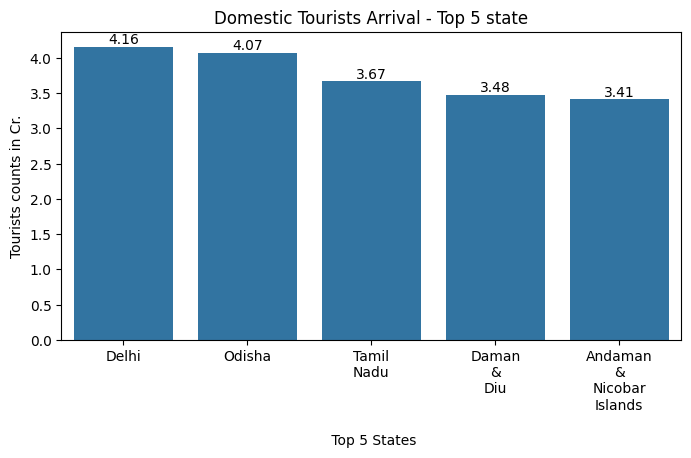

In [841]:
plt.figure(figsize = (8,4))

# Along with plot we are converting value into readable form in Cr
ax = sb.barplot(data = domestic_arrival_tourists,x = 'State',y = round(domestic_arrival_tourists['Domestic Tourists']/10000000,2))

# Trying to warp the state name - after wrapping the state name will be consumable
wrapped_label = [label.replace(" ", "\n") for label in domestic_arrival_tourists['State']]

plt.title("Domestic Tourists Arrival - Top 5 state")
plt.ylabel("Tourists counts in Cr.")
plt.xlabel("\n Top 5 States")
plt.xticks(ticks=range(len(wrapped_label)),labels = wrapped_label)

for bar in ax.containers:
    ax.bar_label(bar)

plt.show()

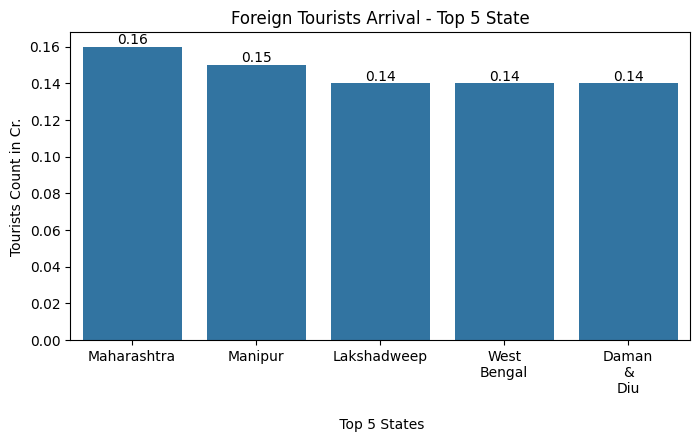

In [842]:
plt.figure(figsize= (8,4))
ax= sb.barplot(data = Foreign_arrival_tourists, x = 'State' , y= round(Foreign_arrival_tourists['Foreign Tourists']/10000000,2))
wrapped_label = [ label.replace(" ", "\n")for label in Foreign_arrival_tourists['State']]

plt.title("Foreign Tourists Arrival - Top 5 State")
plt.ylabel("Tourists Count in Cr.")
plt.xlabel("\n Top 5 States")

plt.xticks(ticks = range(len(wrapped_label)),  labels= wrapped_label)

for bar in ax.containers:
    ax.bar_label(bar)

plt.show()

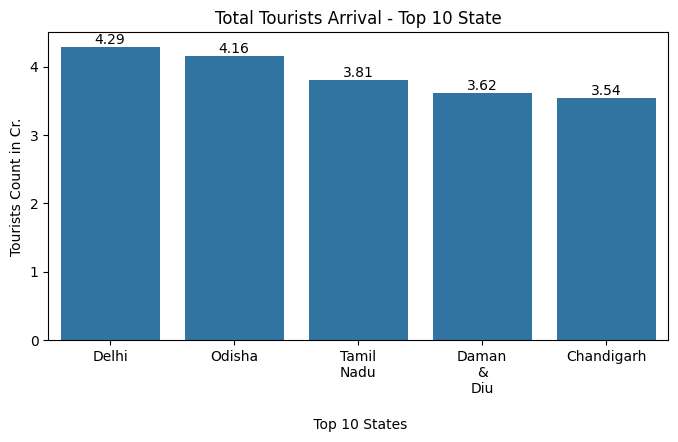

In [843]:
plt.figure(figsize= (8,4))
ax= sb.barplot(data = Total_arrival_tourists, x = 'State' , y= round(Total_arrival_tourists['Total Tourists']/10000000,2))
wrapped_label = [ label.replace(" ", "\n")for label in Total_arrival_tourists['State']]

plt.title("Total Tourists Arrival - Top 10 State")
plt.ylabel("Tourists Count in Cr.")
plt.xlabel("\n Top 10 States")

plt.xticks(ticks = range(len(wrapped_label)),  labels= wrapped_label)

for bar in ax.containers:
    ax.bar_label(bar)

plt.show()

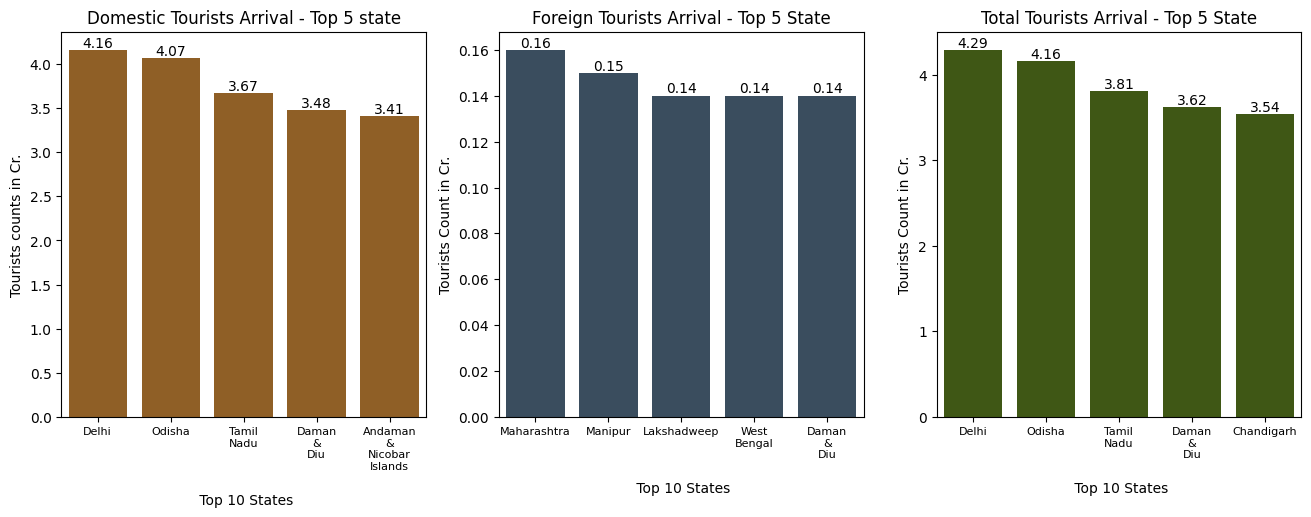

<Figure size 800x400 with 0 Axes>

In [844]:
fig, axes = plt.subplots(1, 3, figsize = (16,5))

# ------------------ Domestic------------------
# Trying to warp the state name - after wrapping the state name will be consumable
wrapped_label = [label.replace(" ", "\n") for label in domestic_arrival_tourists['State']]
# Along with plot we are converting value into readable form in Cr

ax1 = sb.barplot(data = domestic_arrival_tourists,x = 'State',y = round(domestic_arrival_tourists['Domestic Tourists']/10000000,2),ax= axes[0],color= "#A06115")


axes[0].set_title("Domestic Tourists Arrival - Top 5 state")
axes[0].set_ylabel("Tourists counts in Cr.")
axes[0].set_xlabel("\n Top 10 States")
axes[0].set_xticks(ticks=range(len(wrapped_label)),labels = wrapped_label,fontsize=8)

for bar in ax1.containers:
    ax1.bar_label(bar)

# ------------------ Foreign------------------

ax2= sb.barplot(data = Foreign_arrival_tourists, x = 'State' , y= round(Foreign_arrival_tourists['Foreign Tourists']/10000000,2), ax= axes[1],color="#344D64")

wrapped_label = [ label.replace(" ", "\n")for label in Foreign_arrival_tourists['State']]

axes[1].set_title("Foreign Tourists Arrival - Top 5 State")
axes[1].set_ylabel("Tourists Count in Cr.")
axes[1].set_xlabel("\n Top 10 States")

axes[1].set_xticks(ticks = range(len(wrapped_label)),labels= wrapped_label,fontsize=8)

for bar in ax2.containers:
    ax2.bar_label(bar)



# ------------------ Foreign------------------

plt.figure(figsize= (8,4))
ax3= sb.barplot(data = Total_arrival_tourists, x = 'State' , y= round(Total_arrival_tourists['Total Tourists']/10000000,2),ax = axes[2],color= "#42620A")

wrapped_label = [ label.replace(" ", "\n")for label in Total_arrival_tourists['State']]

axes[2].set_title("Total Tourists Arrival - Top 5 State")
axes[2].set_ylabel("Tourists Count in Cr.")
axes[2].set_xlabel("\n Top 10 States")

axes[2].set_xticks(ticks = range(len(wrapped_label)),  labels= wrapped_label,fontsize=8)

for bar in ax3.containers:
    ax3.bar_label(bar)

plt.show()
    




In [845]:
ad = Arrival_data
ad['Domestic Tourists'] = round(ad['Domestic Tourists']/10000000,3)
ad['Foreign Tourists'] = round(ad['Foreign Tourists']/10000000,3)
ad['Total Tourists'] = round(ad['Total Tourists']/10000000,3)

ad.sort_values(by= 'Total Tourists', ascending= False).head(10)



,State,Domestic Tourists,Foreign Tourists,Total Tourists
8,Delhi,4.163,0.122,4.286
25,Odisha,4.070,0.089,4.159
30,Tamil Nadu,3.674,0.141,3.814
7,Daman & Diu,3.481,0.143,3.625
5,Chandigarh,3.405,0.137,3.542
0,Andaman & Nicobar Islands,3.410,0.108,3.519
4,Bihar,3.315,0.120,3.435
11,Haryana,3.314,0.106,3.420
1,Andhra Pradesh,3.304,0.093,3.397
3,Assam,3.239,0.141,3.381


In [846]:
ad.sort_values(by= 'Foreign Tourists', ascending= False).head(10)


,State,Domestic Tourists,Foreign Tourists,Total Tourists
20,Maharashtra,2.919,0.157,3.076
21,Manipur,2.541,0.152,2.694
18,Lakshadweep,3.151,0.144,3.296
35,West Bengal,2.676,0.144,2.820
7,Daman & Diu,3.481,0.143,3.625
3,Assam,3.239,0.141,3.381
30,Tamil Nadu,3.674,0.141,3.814
26,Puducherry,2.971,0.140,3.111
5,Chandigarh,3.405,0.137,3.542
14,Jharkhand,2.640,0.135,2.774


In [847]:
ad.sort_values(by= 'Domestic Tourists', ascending= False).head(10)


,State,Domestic Tourists,Foreign Tourists,Total Tourists
8,Delhi,4.163,0.122,4.286
25,Odisha,4.070,0.089,4.159
30,Tamil Nadu,3.674,0.141,3.814
7,Daman & Diu,3.481,0.143,3.625
0,Andaman & Nicobar Islands,3.410,0.108,3.519
5,Chandigarh,3.405,0.137,3.542
4,Bihar,3.315,0.120,3.435
11,Haryana,3.314,0.106,3.420
1,Andhra Pradesh,3.304,0.093,3.397
3,Assam,3.239,0.141,3.381


In [848]:
# df['Purpose of Visit'].unique()

df.columns

Index(['State', 'Month', 'Date', 'Month_Number', 'Domestic Tourists',
       'Foreign Tourists', 'Total Tourists', 'Tourism Revenue (INR Crore)',
       'Revenue_Per_Tourist_INR', 'Domestic_Spend_Per_Person_INR',
       'Foreign_Spend_Per_Person_INR', 'Est_Domestic_Revenue_Crore',
       'Est_Foreign_Revenue_Crore', 'Domestic_Revenue_Percent',
       'Foreign_Revenue_Percent', 'Annual_Avg_Revenue', 'Seasonality_Index',
       'Seasonality_Ratio', 'Purpose of Visit', 'Growth % (Approx.)'],
      dtype='object')

In [849]:
ad1 = Arrival_data
ad1['tourists_composition_domestic_in_per']= round(ad1['Domestic Tourists']/ad1['Total Tourists']*100,2)
ad1['tourists_composition_foreign_in_per']= round(ad1['Foreign Tourists']/ad1['Total Tourists']*100,2)

composition_data = ad1.sort_values(by = 'tourists_composition_foreign_in_per', ascending= False)
composition_data.head(5)

,State,Domestic Tourists,Foreign Tourists,Total Tourists,tourists_composition_domestic_in_per,tourists_composition_foreign_in_per
21,Manipur,2.541,0.152,2.694,94.32,5.64
35,West Bengal,2.676,0.144,2.820,94.89,5.11
20,Maharashtra,2.919,0.157,3.076,94.90,5.10
15,Karnataka,2.552,0.133,2.685,95.05,4.95
14,Jharkhand,2.640,0.135,2.774,95.17,4.87


In [850]:
df['Purpose of Visit'].unique()

array(['Adventure', 'Business', 'Religious', 'Medical', 'Leisure'],
      dtype=object)

In [851]:
top_5_state = Total_arrival_tourists['State'].head(5)
top_5_state = top_5_state.tolist()
top_5_state



['Delhi', 'Odisha', 'Tamil Nadu', 'Daman & Diu', 'Chandigarh']

In [852]:
total_tourist_visit_purpose = df[df['State'].isin(top_5_state)]
total_tourist_visit_purpose.head(5)

,State,Month,Date,Month_Number,Domestic Tourists,Foreign Tourists,Total Tourists,Tourism Revenue (INR Crore),Revenue_Per_Tourist_INR,Domestic_Spend_Per_Person_INR,Foreign_Spend_Per_Person_INR,Est_Domestic_Revenue_Crore,Est_Foreign_Revenue_Crore,Domestic_Revenue_Percent,Foreign_Revenue_Percent,Annual_Avg_Revenue,Seasonality_Index,Seasonality_Ratio,Purpose of Visit,Growth % (Approx.)
60,Chandigarh,January,2025-01-01,1,3753468,174532,3928000,96.12,244.704684,215.922559,863.690236,81.045842,15.074158,84.317355,15.682645,47.32,103.127642,2.031276,Religious,-3.63
61,Chandigarh,February,2025-02-01,2,1564507,185991,1750498,29.61,169.151864,128.266719,513.066874,20.067418,9.542582,67.772435,32.227565,47.32,-37.426036,0.625740,Business,-4.62
62,Chandigarh,March,2025-03-01,3,4066454,52591,4119045,67.58,164.067156,158.014674,632.058694,64.255940,3.324060,95.081296,4.918704,47.32,42.814877,1.428149,Medical,6.79
63,Chandigarh,April,2025-04-01,4,4463830,83077,4546907,67.54,148.540535,140.821636,563.286544,62.860384,4.679616,93.071342,6.928658,47.32,42.730347,1.427303,Adventure,14.55
64,Chandigarh,May,2025-05-01,5,907686,103291,1010977,13.06,129.181970,98.875724,395.502896,8.974811,4.085189,68.719839,31.280161,47.32,-72.400676,0.275993,Business,4.42


In [853]:
pivot_df = total_tourist_visit_purpose.pivot_table(
                                                   columns= 'Purpose of Visit'
                                                   ,index= 'State'
                                                   ,values= 'Total Tourists'
                                                   ,aggfunc= 'sum'
                                                   ,fill_value= 0
                                                   ,margins= True)

pivot_in_lacs = round(pivot_df/100000,1)
pivot_in_lacs_sorted = pivot_in_lacs.sort_values(by='All', ascending= False).drop(index='All', columns= 'All')



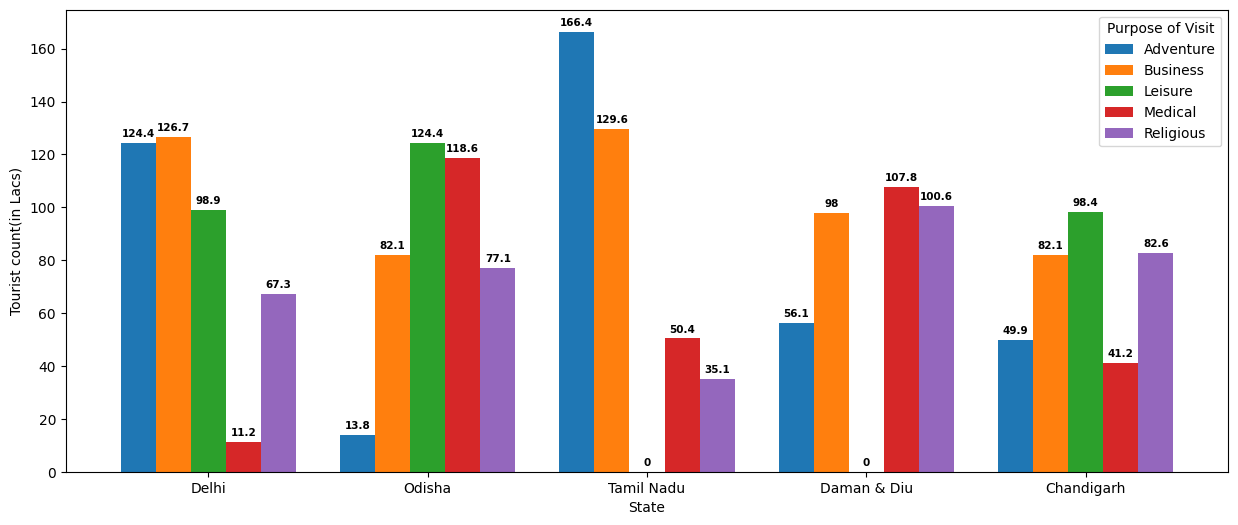

In [854]:
ax = pivot_in_lacs_sorted.plot(kind ='bar', figsize=(15,6), width=0.8)
plt.xticks(rotation = 0, fontsize = 10)
plt.ylabel('Tourist count(in Lacs)')
for bar in ax.containers:
    ax.bar_label(bar, fontsize = 7.5, padding= 3, fontweight ='bold')



# 2. Seasonality and peak travel period analysis


In [855]:
df.columns

Index(['State', 'Month', 'Date', 'Month_Number', 'Domestic Tourists',
       'Foreign Tourists', 'Total Tourists', 'Tourism Revenue (INR Crore)',
       'Revenue_Per_Tourist_INR', 'Domestic_Spend_Per_Person_INR',
       'Foreign_Spend_Per_Person_INR', 'Est_Domestic_Revenue_Crore',
       'Est_Foreign_Revenue_Crore', 'Domestic_Revenue_Percent',
       'Foreign_Revenue_Percent', 'Annual_Avg_Revenue', 'Seasonality_Index',
       'Seasonality_Ratio', 'Purpose of Visit', 'Growth % (Approx.)'],
      dtype='object')

In [856]:
Seasonality_travel_period_pivot = round(df.pivot_table(
                                            values= 'Seasonality_Ratio'
                                            ,index='Month_Number'
                                            ,fill_value= 0
                                            ,aggfunc= 'sum'
                                            ,margins=True
                                            
),2).drop('All',axis=0)

Seasonality_travel_period_pivot 

,Seasonality_Ratio
Month_Number,
1,37.34
2,28.18
3,37.45
4,30.20
5,34.09
6,37.50
7,38.01
8,35.84
9,40.20


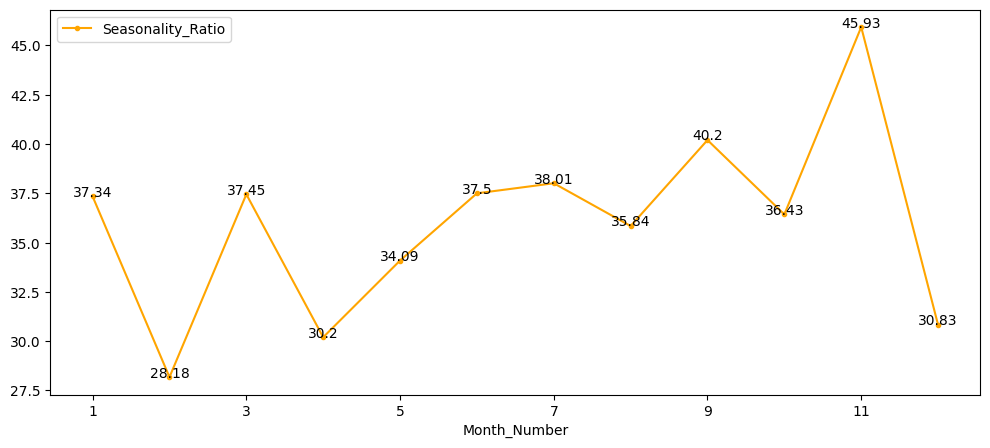

In [857]:
ax = Seasonality_travel_period_pivot.plot(kind = 'line', marker= '.', figsize=(12,5), color = 'orange')

x = range(len(Seasonality_travel_period_pivot))
y = Seasonality_travel_period_pivot['Seasonality_Ratio'].values

for i in range(len(x)):
    ax.text(x[i],y[i], str(y[i]),ha = 'center')

plt.show()

# peak_travel_period_pivot.index

In [858]:
peak_time_tourists_in_cr =round(df.pivot_table(values= 'Total Tourists'
                                ,index= 'Month_Number'
                                ,aggfunc= sum
                                ,fill_value= 0     
                                )/10000000,2)

/var/folders/ll/c36swdyj07g5q0khdbkr9l3w0000gn/T/ipykernel_7962/2855552571.py:1: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  peak_time_tourists_in_cr =round(df.pivot_table(values= 'Total Tourists'


In [859]:
peak_time_tourists_in_cr


,Total Tourists
Month_Number,
1,9.84
2,6.71
3,9.32
4,8.76
5,9.04
6,9.77
7,9.67
8,9.95
9,9.64


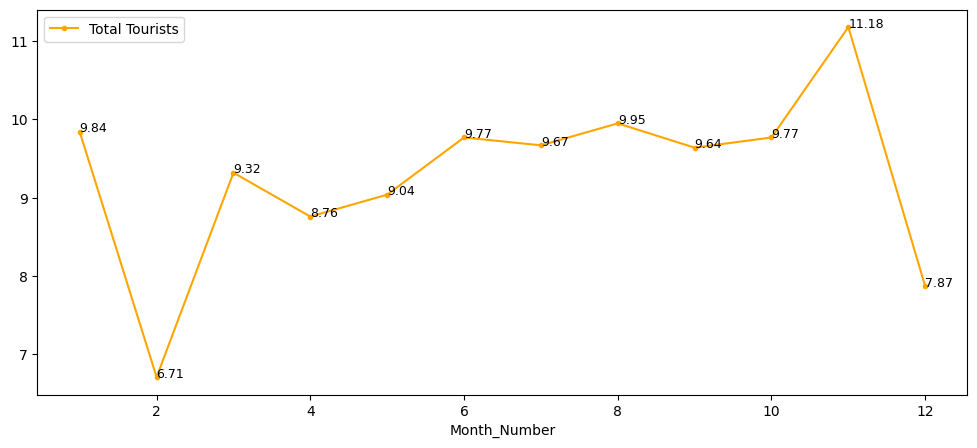

In [860]:
ax = peak_time_tourists_in_cr.plot(kind = 'line',marker= '.', figsize= (12,5), color = 'orange')

x = list(peak_time_tourists_in_cr.index)
y = peak_time_tourists_in_cr['Total Tourists'].values

for i in range(len(x)):
    ax.text(x[i],y[i],str(y[i]),fontsize =9)

plt.show()

In [861]:
from sklearn import linear_model

In [862]:
# %matplotlib inline
# plt

df.columns

Index(['State', 'Month', 'Date', 'Month_Number', 'Domestic Tourists',
       'Foreign Tourists', 'Total Tourists', 'Tourism Revenue (INR Crore)',
       'Revenue_Per_Tourist_INR', 'Domestic_Spend_Per_Person_INR',
       'Foreign_Spend_Per_Person_INR', 'Est_Domestic_Revenue_Crore',
       'Est_Foreign_Revenue_Crore', 'Domestic_Revenue_Percent',
       'Foreign_Revenue_Percent', 'Annual_Avg_Revenue', 'Seasonality_Index',
       'Seasonality_Ratio', 'Purpose of Visit', 'Growth % (Approx.)'],
      dtype='object')

In [873]:
revenue_pivot = round(df.pivot_table(values= 'Tourism Revenue (INR Crore)'
               ,index= 'Month_Number'
               ,aggfunc= sum
               ,fill_value=0),2)

revenue_pivot = revenue_pivot.reset_index()
revenue_pivot

/var/folders/ll/c36swdyj07g5q0khdbkr9l3w0000gn/T/ipykernel_7962/3733668765.py:1: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  revenue_pivot = round(df.pivot_table(values= 'Tourism Revenue (INR Crore)'


,Month_Number,Tourism Revenue (INR Crore)
0,1,1486.72
1,2,1105.56
2,3,1426.58
3,4,1209.24
4,5,1326.78
5,6,1532.89
6,7,1506.48
7,8,1439.75
8,9,1593.00
9,10,1434.45


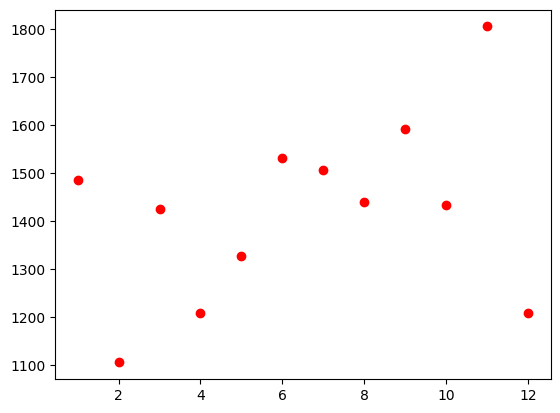

In [874]:
%matplotlib inline
plt.scatter(revenue_pivot['Month_Number'],revenue_pivot['Tourism Revenue (INR Crore)'], color= 'red')

In [885]:
#creating regersiion model 
reg = linear_model.LinearRegression()
reg.fit(revenue_pivot[['Month_Number']],revenue_pivot['Tourism Revenue (INR Crore)'])
reg.predict([[13]])

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([1549.11166667])

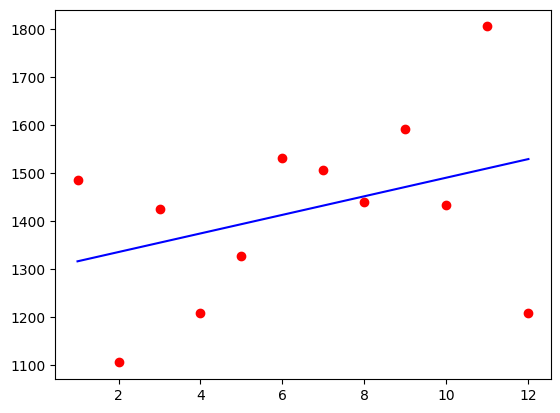

In [892]:
%matplotlib inline
plt.scatter(revenue_pivot['Month_Number'],revenue_pivot['Tourism Revenue (INR Crore)'], color= 'red')

y_pred = reg.predict(revenue_pivot[['Month_Number']])

plt.plot(revenue_pivot['Month_Number'],
         y_pred,
         color = 'blue')
